# 1. Problem statement

In [ ]:
# Transaction anomaly detection using machine lenaring

The objective of this project is to identify unusual or abnormal transaction from
transaction data using machine learning.

In real world transaction datasets most transaction follow normal patterns
while some transaction may have unusual values or behavior

Our goal is to analyze transaction data and built a machine learning model that can
identify such unusual transaction automatically

Key objective
1. understand the transaction dataset
2. Perform Exploratory data analysis (EDA)
3. Clean data preprocess the data
4. select relavant data
5. apply an anomaly detection machine leanring algorithm
6. evaluate the mode
7. test the model on a single new transaction
8. save the trained model for future use

# 2. import library

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix

import pickle
import warnings
warnings.filterwarnings('ignore')

# 3. Data Gathering

In [ ]:
df = pd.read_csv(r"C:\Users\WINDOWS 11-23H2\Downloads\transactions.csv")

In [ ]:
df.head(2)

,Transaction_ID,Transaction_Date,Customer_Age,Transaction_Amount,Transaction_Count_24H,Account_Age_Days,Device_Type,Payment_Method,Location,Is_International
0,TXN00522,2026-03-04,49.0,1831.56,5,2368,Desktop,UPI,Hyderabad,No
1,TXN00738,2026-04-09,58.0,1435.19,1,1806,Tablet,UPI,Indore,No


In [ ]:
df.shape

(1003, 10)

In [ ]:
df.columns

Index(['Transaction_ID', 'Transaction_Date', 'Customer_Age',
       'Transaction_Amount', 'Transaction_Count_24H', 'Account_Age_Days',
       'Device_Type', 'Payment_Method', 'Location', 'Is_International'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1003 entries, 0 to 1002
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Transaction_ID         1003 non-null   object 
 1   Transaction_Date       1003 non-null   object 
 2   Customer_Age           998 non-null    float64
 3   Transaction_Amount     1000 non-null   float64
 4   Transaction_Count_24H  1003 non-null   int64  
 5   Account_Age_Days       1003 non-null   int64  
 6   Device_Type            999 non-null    object 
 7   Payment_Method         1001 non-null   object 
 8   Location               1003 non-null   object 
 9   Is_International       1003 non-null   object 
dtypes: float64(2), int64(2), object(6)
memory usage: 78.5+ KB


# 4. EDA + preprocessing

## 1. missing values

In [ ]:
df.isnull().sum()

Transaction_ID           0
Transaction_Date         0
Customer_Age             5
Transaction_Amount       3
Transaction_Count_24H    0
Account_Age_Days         0
Device_Type              4
Payment_Method           2
Location                 0
Is_International         0
dtype: int64

In [ ]:
missing_per= (df.isnull().sum() / len(df))*100
missing_per.sort_values(ascending=False)

Customer_Age             0.498504
Device_Type              0.398804
Transaction_Amount       0.299103
Payment_Method           0.199402
Transaction_ID           0.000000
Transaction_Date         0.000000
Transaction_Count_24H    0.000000
Account_Age_Days         0.000000
Location                 0.000000
Is_International         0.000000
dtype: float64

In [ ]:
df[['Customer_Age', 'Device_Type', 'Transaction_Amount', 'Payment_Method']].head(2)

,Customer_Age,Device_Type,Transaction_Amount,Payment_Method
0,49.0,Desktop,1831.56,UPI
1,58.0,Tablet,1435.19,UPI


In [ ]:
nume_columns = df[['Customer_Age','Transaction_Amount']]

for i in nume_columns:
    df[i] = df[i].fillna(df[i].median())

In [ ]:
# df.isna().sum()

In [ ]:
cate_col = df[['Device_Type','Payment_Method']]
for i in cate_col:
    df[i] = df[i].fillna(df[i].mode()[0])

In [ ]:
# df.isna().sum()

In [ ]:

# df[i].fillna(df[i].mode()[0])

'Mobile'

## 2. Duplicate records

In [ ]:
df.duplicated().sum()

3

In [ ]:
df = df.drop_duplicates().reset_index(drop=True)

In [ ]:
df.shape

(1000, 10)

In [ ]:
df.head(2)

,Transaction_ID,Transaction_Date,Customer_Age,Transaction_Amount,Transaction_Count_24H,Account_Age_Days,Device_Type,Payment_Method,Location,Is_International
0,TXN00522,2026-03-04,49.0,1831.56,5,2368,Desktop,UPI,Hyderabad,No
1,TXN00738,2026-04-09,58.0,1435.19,1,1806,Tablet,UPI,Indore,No


## 3. Date feature analysis

In [ ]:
# df['Transaction_Date']     # '2026-03-04'
# transaction_date column dtype is object but we want date and time
# so, by using pandas date and time function we convert in datetime

In [ ]:
df['Transaction_Date'] = pd.to_datetime(df['Transaction_Date'])

### new features

In [ ]:
df['Transaction_Year']=df['Transaction_Date'].dt.year
df['Transaction_Month']=df['Transaction_Date'].dt.month
df['Transaction_Day']=df['Transaction_Date'].dt.day
df['Transaction_DayOfWeek']=df['Transaction_Date'].dt.dayofweek

In [ ]:
df.shape

(1000, 14)

In [ ]:
df['Is_Weekend']=df['Transaction_DayOfWeek'].isin([5,6]).astype(int)

In [ ]:
df.drop('Transaction_Date', axis=1, inplace=True)

In [ ]:
df.head(1)

,Transaction_ID,Customer_Age,Transaction_Amount,Transaction_Count_24H,Account_Age_Days,Device_Type,Payment_Method,Location,Is_International,Transaction_Year,Transaction_Month,Transaction_Day,Transaction_DayOfWeek,Is_Weekend
0,TXN00522,49.0,1831.56,5,2368,Desktop,UPI,Hyderabad,No,2026,3,4,2,0


## 4. outlier analysis

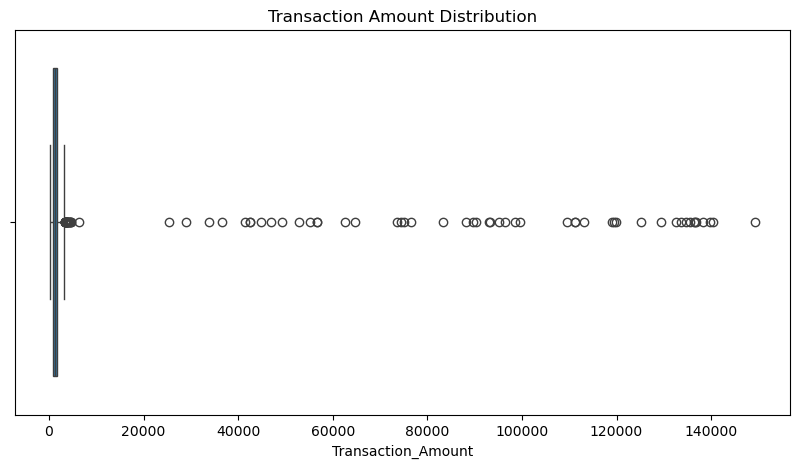

In [ ]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df, x='Transaction_Amount')
plt.title("Transaction Amount Distribution")
plt.show()

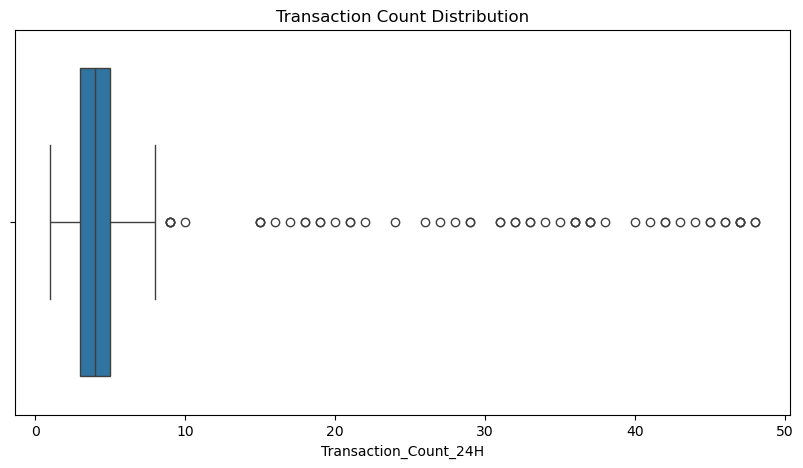

In [ ]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df, x='Transaction_Count_24H')
plt.title("Transaction Count Distribution")
plt.show()

In [ ]:
# summary
Normally outliers remove kiye jaate hain, lekin anomaly detection mein
unusual observation hi detet krna hain. isliye genuine  extrem
values ko remove nahi karenge

## 5. Categorical Encoding

In [ ]:
df

,Transaction_ID,Customer_Age,Transaction_Amount,Transaction_Count_24H,Account_Age_Days,Device_Type,Payment_Method,Location,Is_International,Transaction_Year,Transaction_Month,Transaction_Day,Transaction_DayOfWeek,Is_Weekend
0,TXN00522,49.0,1831.56,5,2368,Desktop,UPI,Hyderabad,No,2026,3,4,2,0
1,TXN00738,58.0,1435.19,1,1806,Tablet,UPI,Indore,No,2026,4,9,3,0
2,TXN00741,20.0,1373.89,5,1003,Mobile,Wallet,Pune,No,2026,1,17,5,1
3,TXN00661,45.0,3072.71,8,2061,Mobile,UPI,Hyderabad,No,2026,3,25,2,0
4,TXN00412,43.0,977.38,3,589,Mobile,UPI,Pune,No,2026,4,20,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,TXN00107,27.0,1068.70,4,627,Mobile,Card,Hyderabad,No,2026,3,28,5,1
996,TXN00271,45.0,704.85,3,745,Mobile,UPI,Bengaluru,No,2026,4,23,3,0
997,TXN00861,46.0,1203.22,4,300,Mobile,NetBanking,Hyderabad,Yes,2026,2,2,0,0
998,TXN00436,49.0,764.11,4,1219,Mobile,UPI,Bengaluru,No,2026,3,5,3,0


In [ ]:
df.select_dtypes(include='object')

,Transaction_ID,Device_Type,Payment_Method,Location,Is_International
0,TXN00522,Desktop,UPI,Hyderabad,No
1,TXN00738,Tablet,UPI,Indore,No
2,TXN00741,Mobile,Wallet,Pune,No
3,TXN00661,Mobile,UPI,Hyderabad,No
4,TXN00412,Mobile,UPI,Pune,No
...,...,...,...,...,...
995,TXN00107,Mobile,Card,Hyderabad,No
996,TXN00271,Mobile,UPI,Bengaluru,No
997,TXN00861,Mobile,NetBanking,Hyderabad,Yes
998,TXN00436,Mobile,UPI,Bengaluru,No


In [ ]:
df['Is_International'].value_counts()

Is_International
No     906
Yes     94
Name: count, dtype: int64

In [ ]:
df.select_dtypes(include='object').columns

Index(['Transaction_ID', 'Device_Type', 'Payment_Method', 'Location',
       'Is_International'],
      dtype='object')

In [ ]:
# one hot encoding

df = pd.get_dummies(df, columns = ['Device_Type',
                              'Payment_Method',
                              'Location',
                              'Is_International'],
              drop_first = True, dtype=int)

In [ ]:
df.drop('Transaction_ID', axis=1, inplace = True)

# 5. train test split

In [ ]:
x = df

In [ ]:
x.shape

(1000, 20)

In [ ]:
x_train, x_test=train_test_split(x, test_size=0.20, random_state=42)

# 6. model training

In [ ]:
model = IsolationForest(n_estimators=200, random_state=42)

In [ ]:
model.fit(x_train)

IsolationForest(n_estimators=200, random_state=42)

# 7. model evaluation

In [ ]:
train_prediction = model.predict(x_train)
test_prediction = model.predict(x_test)

print("train is :",train_prediction)
print("test is  :",test_prediction)

# isolationforest output
# 1   --> Normal data
# -1  --> abnormal data

train is : [ 1 -1  1  1  1  1 -1  1  1  1  1  1  1 -1  1 -1  1  1 -1  1 -1  1  1  1
 -1 -1 -1 -1  1 -1 -1 -1  1  1 -1  1 -1 -1  1 -1  1  1  1  1  1  1  1  1
 -1  1  1  1  1  1  1  1 -1  1  1  1 -1  1  1 -1 -1 -1 -1  1  1 -1  1  1
 -1  1  1  1 -1  1  1  1  1  1  1 -1  1  1  1  1  1  1  1  1 -1  1  1  1
 -1  1  1 -1  1  1  1  1  1  1  1  1 -1  1 -1  1  1  1  1  1  1 -1  1 -1
  1  1 -1  1  1  1  1  1  1 -1 -1  1 -1  1  1 -1 -1 -1 -1 -1  1 -1  1  1
  1  1  1 -1  1  1  1  1  1  1 -1  1  1 -1  1 -1 -1  1 -1  1  1 -1 -1  1
 -1  1 -1 -1  1 -1  1 -1  1  1 -1 -1  1  1 -1  1  1  1  1 -1  1  1  1  1
  1  1 -1  1  1 -1  1 -1  1 -1  1 -1 -1  1 -1  1 -1  1  1  1 -1  1  1  1
 -1  1 -1  1 -1  1  1  1  1 -1  1 -1  1 -1  1  1 -1 -1  1  1  1  1  1 -1
  1  1 -1  1 -1  1  1  1  1  1  1  1  1 -1 -1  1  1 -1  1 -1  1  1  1 -1
 -1 -1  1 -1  1  1  1  1  1  1  1 -1 -1  1 -1  1 -1  1  1  1 -1 -1  1  1
  1  1  1  1  1  1  1 -1  1  1  1 -1 -1 -1  1  1  1 -1  1 -1  1  1 -1  1
 -1  1  1  1 -1  1 -1  1  1 -1  1  1  1 

In [ ]:
x_test_result = x_test.copy()
x_test_result['Anomaly'] = test_prediction

In [ ]:
x_test_result.head()

,Customer_Age,Transaction_Amount,Transaction_Count_24H,Account_Age_Days,Transaction_Year,Transaction_Month,Transaction_Day,Transaction_DayOfWeek,Is_Weekend,Device_Type_Mobile,...,Payment_Method_NetBanking,Payment_Method_UPI,Payment_Method_Wallet,Location_Delhi,Location_Hyderabad,Location_Indore,Location_Mumbai,Location_Pune,Is_International_Yes,Anomaly
521,35.0,1431.68,4,1064,2026,2,2,0,0,1,...,0,0,0,0,0,0,0,0,0,1
737,44.0,1128.42,3,1785,2026,1,1,3,0,1,...,0,0,0,0,0,1,0,0,0,1
740,54.0,1217.15,4,1830,2026,1,14,2,0,0,...,0,1,0,0,0,0,0,0,0,1
660,53.0,4112.88,2,1613,2026,2,17,1,0,0,...,0,0,1,1,0,0,0,0,0,-1
411,20.0,1080.82,5,1027,2026,4,10,4,0,1,...,0,0,0,0,0,0,0,1,0,1


In [ ]:
0 - Normal
1 - abnormal

target

In [ ]:
normal_count = np.sum(test_prediction==1)
abnormal_count = np.sum(test_prediction==-1)

In [ ]:
print("Normal transaction :",normal_count)
print("Abnormal transaction :",abnormal_count)

Normal transaction : 126
Abnormal transaction : 74


In [ ]:
normal_per = (normal_count/ len(test_prediction)) * 100
abnormal_per = (abnormal_count/ len(test_prediction)) * 100

In [ ]:
# isolation forest score
score = model.decision_function(x_test)

In [ ]:
x_test_result['anomaly_score'] = score

In [ ]:
x_test_result.head(1)

,Customer_Age,Transaction_Amount,Transaction_Count_24H,Account_Age_Days,Transaction_Year,Transaction_Month,Transaction_Day,Transaction_DayOfWeek,Is_Weekend,Device_Type_Mobile,...,Payment_Method_UPI,Payment_Method_Wallet,Location_Delhi,Location_Hyderabad,Location_Indore,Location_Mumbai,Location_Pune,Is_International_Yes,Anomaly,anomaly_score
521,35.0,1431.68,4,1064,2026,2,2,0,0,1,...,0,0,0,0,0,0,0,0,1,0.08728


In [ ]:
x_test_result.sort_values(by='anomaly_score').head(10)

,Customer_Age,Transaction_Amount,Transaction_Count_24H,Account_Age_Days,Transaction_Year,Transaction_Month,Transaction_Day,Transaction_DayOfWeek,Is_Weekend,Device_Type_Mobile,...,Payment_Method_UPI,Payment_Method_Wallet,Location_Delhi,Location_Hyderabad,Location_Indore,Location_Mumbai,Location_Pune,Is_International_Yes,Anomaly,anomaly_score
662,26.0,74406.76,38,3,2026,1,17,5,1,0,...,0,1,1,0,0,0,0,1,-1,-0.179649
86,22.0,136503.76,42,8,2026,1,1,3,0,0,...,0,1,0,1,0,0,0,1,-1,-0.171797
941,46.0,134644.83,48,8,2026,3,24,1,0,0,...,0,0,0,0,0,1,0,1,-1,-0.146803
917,34.0,93315.31,32,13,2026,1,5,0,0,0,...,0,0,0,0,0,1,0,1,-1,-0.136495
107,46.0,113035.53,29,6,2026,1,11,6,1,0,...,0,0,1,0,0,0,0,0,-1,-0.135713
767,37.0,139689.75,47,3,2026,4,5,6,1,0,...,0,0,0,0,0,0,0,1,-1,-0.132965
643,40.0,111236.09,33,12,2026,2,28,5,1,1,...,1,0,0,0,0,1,0,1,-1,-0.122482
237,47.0,62528.18,33,21,2026,3,30,0,0,0,...,1,0,0,0,0,0,0,1,-1,-0.115360
899,63.0,90227.90,21,28,2026,3,14,5,1,0,...,1,0,0,0,0,0,0,1,-1,-0.114483
425,23.0,2143.77,3,455,2026,4,26,6,1,1,...,0,0,0,0,0,0,1,1,-1,-0.091799


In [ ]:
df[df['col']==condition]

In [ ]:
a = x_test_result[x_test_result['Anomaly'] == -1]

In [ ]:
a[['Transaction_Amount', 'Anomaly']].head(10)

,Transaction_Amount,Anomaly
660,4112.88,-1
626,3433.70,-1
636,1229.80,-1
899,90227.90,-1
527,1495.40,-1
210,624.82,-1
902,4531.64,-1
947,725.18,-1
346,2520.97,-1
499,2199.84,-1


# check on single row

In [ ]:
df.columns

Index(['Customer_Age', 'Transaction_Amount', 'Transaction_Count_24H',
       'Account_Age_Days', 'Transaction_Year', 'Transaction_Month',
       'Transaction_Day', 'Transaction_DayOfWeek', 'Is_Weekend',
       'Device_Type_Mobile', 'Device_Type_Tablet', 'Payment_Method_NetBanking',
       'Payment_Method_UPI', 'Payment_Method_Wallet', 'Location_Delhi',
       'Location_Hyderabad', 'Location_Indore', 'Location_Mumbai',
       'Location_Pune', 'Is_International_Yes'],
      dtype='object')

In [ ]:
new_transaction= pd.DataFrame({'Customer_Age' : [35],
                                 'Transaction_Amount' : [850000],
                                 'Transaction_Count_24H' : [25],
                                 'Account_Age_Days' : [10],
                                 'Transaction_Year' : [2026],
                                 'Transaction_Month': [9],
                                 'Transaction_Day' : [19],
                                 'Transaction_DayOfWeek' : [4],
                                 'Is_Weekend' : [1],

                                 'Device_Type_Mobile' : [0],
                                 'Device_Type_Tablet' : [0],
                                 'Payment_Method_NetBanking' : [0],
                                 'Payment_Method_UPI' : [1],
                                 'Payment_Method_Wallet' : [0],

                                 'Location_Delhi' : [0],
                                 'Location_Hyderabad' : [0],
                                 'Location_Indore' : [0],
                                 'Location_Mumbai' : [1],
                                'Location_Pune' : [0],

                                 'Is_International_Yes' : [1]})

In [ ]:
#
new_transaction= new_transaction.reindex(columns=x_train.columns, fill_value=0)

In [ ]:
predicted=model.predict(new_transaction)

In [ ]:
if predicted[0] == -1:
    print("Abnormal Detection")

else:
    print("Normal Transaction")

Abnormal Detection


# save model

In [ ]:
# with open('abnormal_model.pkl', 'x') as file:
#     pickle.dump(model, file)

TypeError: write() argument must be str, not bytes

In [ ]:
import joblib

In [ ]:
joblib.dump(model, "abnormal_model.pkl")

['abnormal_model.pkl']